# Demonstrating `uncertainty` module

In this notebook we show the how to use and apply the classess and method in the sub modules of the `uncertainty` module this include:
- Importing uncertainty information
- Filtering uncertain parameters
- selecting and changing probability distribution information of uncertain parameters

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pandas as pd
import numpy as np
sys.path.append('..')
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa
from pulpo.utils import optimizer, saver

## 0. Setup Background and Foreground Databases

### 0.1: Background Database (Ecoinvent 3.10 cutoff)

In [2]:
from pathlib import Path
import bw2data as bd
import bw2io as bi

PROJECT = "ammonia_final"
DB_NAME = "ecoinvent-3.10-cutoff"
CRED_PATH = Path("/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Administration/02_VITO/04_Systems/credentials.txt")

def read_credentials(path: Path):
    if not path.is_file():
        raise FileNotFoundError(f"Couldn't find credentials file at: {path.resolve()}")
    creds = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        # allow "key=value" or "key: value" or "key value"
        for sep in ("=", ":", " "):
            if sep in line:
                k, v = line.split(sep, 1)
                creds[k.strip().lower()] = v.strip()
                break
    if "username" not in creds or "password" not in creds:
        raise ValueError("credentials.txt must contain 'username' and 'password'.")
    return creds["username"], creds["password"]

# 1) Ensure project exists / is selected
bd.projects.set_current(PROJECT)

# 2) Import ecoinvent 3.10 cutoff if missing
if DB_NAME in bd.databases:
    print(f"Database '{DB_NAME}' already exists in project '{bd.projects.current}'.")
else:
    username, password = read_credentials(CRED_PATH)
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",  # "cutoff", "apos", "consequential", or "EN15804"
        username=username,
        password=password,
    )
    print(f"Database '{DB_NAME}' installed successfully.")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_final'.


### 0.2: Foreground Database (Ammonia Production)

In [3]:
# Path to your Excel file
excel_path = r"data/ammonia.xlsx"
fg_db_name = "ammonia"

if fg_db_name in bd.databases:
    print(f"Database '{fg_db_name}' already exists in project '{bd.projects.current}'.")
else:
    # 1. Import the Excel file
    fg_db = bi.ExcelImporter(excel_path)

    # 2. Apply strategies to clean and prepare the data
    fg_db.apply_strategies()

    # 3. Match the foreground database to itself (for internal links)
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])

    # 4. Match to ecoinvent technosphere (use your actual ecoinvent db name)
    fg_db.match_database(
        "ecoinvent-3.10-cutoff",
        fields=["name", "unit", "location", "reference product"]
    )

    # 5. Match to ecoinvent biosphere (biosphere db is usually auto-named, check with list(bd.databases))
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(
        biosphere_db,
        fields=["name", "categories", "location"]
    )

    # 6. Check statistics (should have 0 unlinked exchanges)
    fg_db.statistics()

    # 7. Write the database to disk
    fg_db.write_database()
    print(f"Database '{fg_db_name}' installed successfully.")

Database 'ammonia' already exists in project 'ammonia_final'.


### 0.3: Install premise for GWP characterization factors

**Note:** Before executing the next cell, make sure to install `premise` via:
```bash
pip install premise
```

This package is required for adding updated GWP characterization factors to the project.

In [4]:

# Check if the IPCC 2021 method already exists before adding premise GWP
import bw2data as bd

target_method = ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')

if target_method in bd.methods:
    print(f"Method '{target_method}' already exists in the project.")
else:
    print(f"Method '{target_method}' not found. Adding premise GWP characterization factors...")
    from premise_gwp import add_premise_gwp
    add_premise_gwp()
    print("Premise GWP characterization factors added successfully.")

Method '('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')' already exists in the project.


### 0.4: Install IPCC 2013 GWP method with uncertainty

This method has been obtained and adapted from: https://github.com/aleksandra-kim/gwp_uncertainties

In [5]:
from bw2io.package import BW2Package

target_method = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')

if target_method in bd.methods:
    print(f"Method '{target_method}' already exists in the project.")
else:
    print(f"Method '{target_method}' not found. Importing IPCC 2013 GWP method with uncertainty...")
    BW2Package.import_file("data/ipcc_uncertain.bw2package")
    print("IPCC 2013 GWP with uncertainty characterization factors added successfully.")


Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists in the project.


## 1. Case Study Setup: Ammonia Production System

In [6]:
def setup_ammonia_case_study():
    """
    Set up the ammonia production case study with PULPO configuration.
    
    Returns:
        tuple: (project, database, method, directory) configuration parameters
    """
    project = "ammonia_final"
    database = ["ecoinvent-3.10-cutoff", "ammonia"]
    method = "('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')"
    directory = "develop_tests"
    
    return project, database, method, directory

def create_pulpo_worker(project, database, method, directory):
    """
    Create and initialize a PULPO optimizer instance.
    
    Args:
        project (str): PULPO project name
        database (str): Database name
        method (str): LCIA method specification
        directory (str): Working directory path
        
    Returns:
        pulpo.PulpoOptimizer: Configured PULPO worker instance
    """
    # Create PulpoOptimizer instance
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    
    # Import LCI data
    pulpo_worker.get_lci_data()
    
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """
    Deterministic process retrieval to avoid order issues.
    
    Args:
        worker: PULPO optimizer instance
        query (str): Process name query
        prefer_locations (tuple): Preferred locations in order of preference
        
    Returns:
        Process object from the database
    """
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

def define_ammonia_problem(pulpo_worker):
    """
    Define the ammonia production optimization problem with streamlined configuration.
    
    Args:
        pulpo_worker: PULPO optimizer instance
        
    Returns:
        tuple: (choices, demand) for the optimization problem
    """
    # Choice definitions with capacities bound per-label
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
            ],
            # 2030 EU-27 potentials from biomethane shares (38 bcm total; 24% ag, 21% sequential),
            # converted to raw biogas assuming ~57% CH₄ → 16.0 & 14.0 bcm ≈ 1.60e10 & 1.40e10 m³/yr.
            "capacities": [1.60e10, 1.40e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            # Methane pyrolysis capped to 10,000 t H2/yr (= 1.0e7 kg/yr); others left high for now.
            # "capacities": [3.0e8, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "electricity": {
            "processes": [
                "grid electricity",
                # "wind onshore electricity",
            ],
            "capacities": [1e20],#, 5e10], # Placeholder cap for wind onshore
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}  # ~17.1 Mt/yr (EU)

    # Additional upper bounds (shared resources / feedstocks)
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,#1.875e9,  # 25% of ~7.5 Mt PP post-consumer waste ≈ 1.875 Mt/yr
        waste_ps: 1e20,#3.25e8,   # 25% of ~1.3 Mt PS waste ≈ 0.325 Mt/yr
        ccs_process: 1e20,#5.0e9, # 5 MtCO2/yr (10% of EU-27 2030 NZIA target)
    }
    
    # Instantiate the optimization problem
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    return choices, demand

def solve_and_summarize(pulpo_worker, file_name='ammonia_results'):
    """
    Solve the optimization problem and summarize results.
    
    Args:
        pulpo_worker: PULPO optimizer instance
        file_name (str): Filename for results (optional)
        
    Returns:
        dict: Extracted results data
    """
    # Solve optimization problem
    pulpo_worker.solve(solver_name='gurobi')
    
    # Extract and summarize results
    result_data = pulpo_worker.extract_results()
    pulpo_worker.summarize_results(zeroes=True)
    
    return result_data

# 6. Case study: Integrating epistemic uncertainty factors

## 6.1. Changes in the ammonia database
- Added 0.1 kg 'Carbon dioxide, non-fossil' in 'CCS 200km pipeline 1000m deep'
- Changed "electricity, high voltage	grid electricity	RER	kilowatt hour	('ammonia', '49891e5d8da5e6cf0264c313f6a66376_copy1')" to be the aggregated activity of the ecoinvent version with the 10 most contributing biosphere flows. Then multiplying with 0.25, which represents a 75% decarbonized electricity mix. These biosphere flows are then used to add triag distribution 


Recompute the PULPO worker

In [7]:
# Set up the ammonia case study
project, database, method, directory = setup_ammonia_case_study()

In [8]:
# Create and initialize PULPO worker
pulpo_worker = create_pulpo_worker(project, database, method, directory)

# Define the optimization problem
choices, demand = define_ammonia_problem(pulpo_worker)

Creating Instance
Instance created


In [9]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.UniformBaseStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = .5,
        lower_scaling_factor = .5,
        noise_interval={'min':.2, 'max':.2}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        upper_scaling_factor=.3,
        lower_scaling_factor=.3,
        noise_interval={'min':.2, 'max':.1}
    ),
    
    processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        prob_metadata={
            (715, 23523): {'minimum':.1 ,'maximum':.8, 'uncertainty_type':4}, # CCS 200km pipeline 1000m deep | CO2 stored | RER --- Carbon dioxide, non-fossil | ('air',)
            (80, 23561): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, supercritical carbon dioxide | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
            # For the electricity we assume a triangular distribution with mode = the 75% decarbonized electricity (excel sheet) mix, min = 10% of mode, max = the current mix 
            # (81, 23537): {'loc':.0057, 'minimum':.00057 ,'maximum':.023, 'uncertainty_type':5}, # grid electricity | electricity, high voltage | RER --- Carbon dioxide, in air | ('natural resource', 'in air')
            # (82, 23537): {'loc':.0093, 'minimum':.00093 ,'maximum':.037, 'uncertainty_type':5}, # grid electricity | electricity, high voltage | RER --- Carbon dioxide, non-fossil | ('air', 'urban air close to ground')
            # (716, 23537): {'loc':.0663, 'minimum':.00663 ,'maximum':.265, 'uncertainty_type':5}, # grid electricity | electricity, high voltage | RER --- Carbon dioxide, fossil | ('air', 'non-urban air or from high stacks')
            # Playing around with electricity emissions, now assuming mode: ~90% decarbonized and min=Wind, and max=75% decarbonized
            (81, 23537): {'loc':.002, 'minimum':.00057 ,'maximum':.006, 'uncertainty_type':5}, # grid electricity | electricity, high voltage | RER --- Carbon dioxide, in air | ('natural resource', 'in air')
            (82, 23537): {'loc':.003, 'minimum':.00093 ,'maximum':.009, 'uncertainty_type':5}, # grid electricity | electricity, high voltage | RER --- Carbon dioxide, non-fossil | ('air', 'urban air close to ground')
            (716, 23537): {'loc':.023, 'minimum':.00663 ,'maximum':.069, 'uncertainty_type':5}, # grid electricity | electricity, high voltage | RER --- Carbon dioxide, fossil | ('air', 'non-urban air or from high stacks')
        
        }
    )
    ]

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.750512e+01


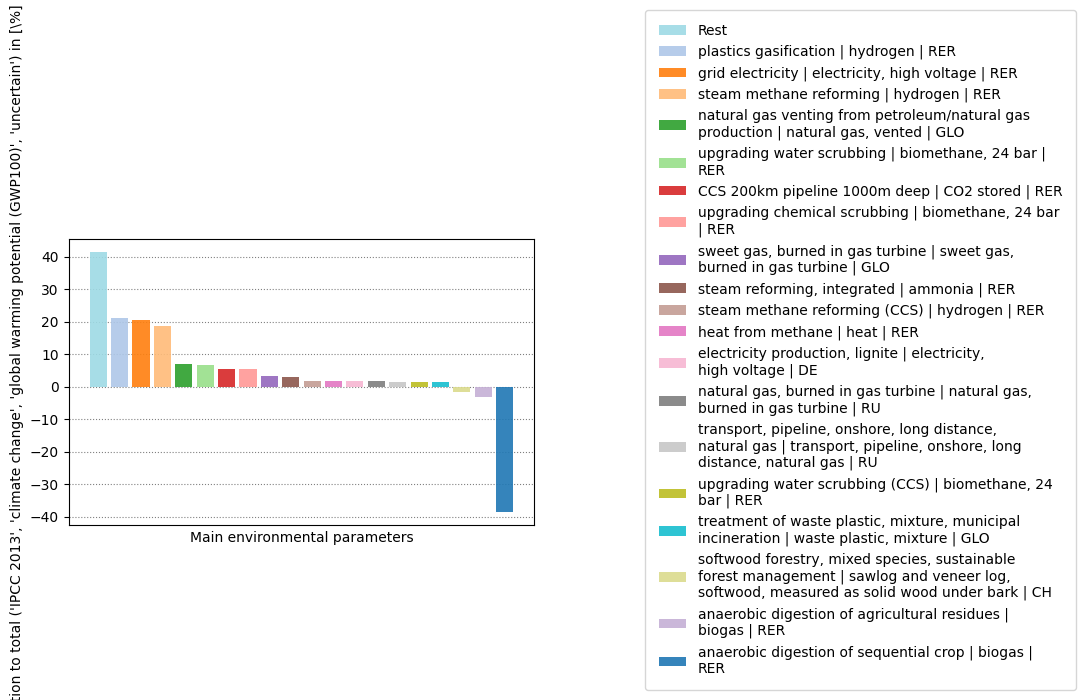

Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 21178
Deviation from LCA score: 0.0
inventory (2648, 23569) filtering resulted in 21178 of 21178 exchanges (100.0% of total impact) and took 0.004 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 82 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 16080 
Parameters without uncertainty information: 5046
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 52
Charactetization factors:
Parameters with uncertainty information: 67 
Parameters without uncertainty information: 15
Variable bounds:
Upper bound from choices without uncertainty information: 22
Upper bound from `upper_limit` without uncertainty information: 3
Lower bound from `lower_limit` without uncertainty information: 0
Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cut

In [10]:
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.,#0.000019,
    scaling_vector_strategy='constructed_demand',
    plot_results=True,
    plot_n_top_processes=19
)
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

In [12]:
lambda_epsilon_array = np.linspace(0.5,1, 5, endpoint=False)
results_CC = pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, solver_name='gurobi')

solving CC problem for lambda_QB = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Applying CC constraints to the upper_limit constraint with lambda: 0.5
Optimization problem solved using gurobi
status=ok, termination=optimal
solving CC problem for lambda_QB = 0.6
Applying CC constraints to the environmental cost calculation with lambda: 0.6
Applying CC constraints to the upper_limit constraint with lambda: 0.6
Optimization problem solved using gurobi
status=ok, termination=optimal
solving CC problem for lambda_QB = 0.7
Applying CC constraints to the environmental cost calculation with lambda: 0.7
Applying CC constraints to the upper_limit constraint with lambda: 0.7
Optimization problem solved using gurobi
status=ok, termination=optimal
solving CC problem for lambda_QB = 0.8
Applying CC constraints to the environmental cost calculation with lambda: 0.8
Applying CC constraints to the upper_limit constraint with lambda: 0.8
Optimization problem solved 

In [14]:
pulpo_worker.uncertainty_data

{'If': {'ecoinvent-3.10-cutoff': {'defined': {(80, 10): {'input': 107,
     'output': 4373,
     'type': 2,
     'uncertainty_type': 2,
     'amount': 0.08640360832214355,
     'loc': -2.448725938796997,
     'scale': 0.31081345677375793,
     'shape': nan,
     'minimum': nan,
     'maximum': nan,
     'negative': False},
    (80, 29): {'input': 107,
     'output': 4392,
     'type': 2,
     'uncertainty_type': 2,
     'amount': 0.08311399817466736,
     'loc': -2.487542152404785,
     'scale': 0.4472135901451111,
     'shape': nan,
     'minimum': nan,
     'maximum': nan,
     'negative': False},
    (80, 46): {'input': 107,
     'output': 4409,
     'type': 2,
     'uncertainty_type': 2,
     'amount': 0.9081197381019592,
     'loc': -0.09637903422117233,
     'scale': 0.2080865204334259,
     'shape': nan,
     'minimum': nan,
     'maximum': nan,
     'negative': False},
    (80, 82): {'input': 107,
     'output': 4445,
     'type': 2,
     'uncertainty_type': 2,
     'amount': 0

With a cutoff value of 0.015, we keep 5 process to an error of 130.49%
With a cutoff value of 0.015, we keep 5 process to an error of 389.78%
With a cutoff value of 0.015, we keep 5 process to an error of 486.46%
With a cutoff value of 0.015, we keep 7 process to an error of 129.79%
With a cutoff value of 0.015, we keep 2 process to an error of 25.63%
by grouping the processes by product, we reduce the number of variables to 11


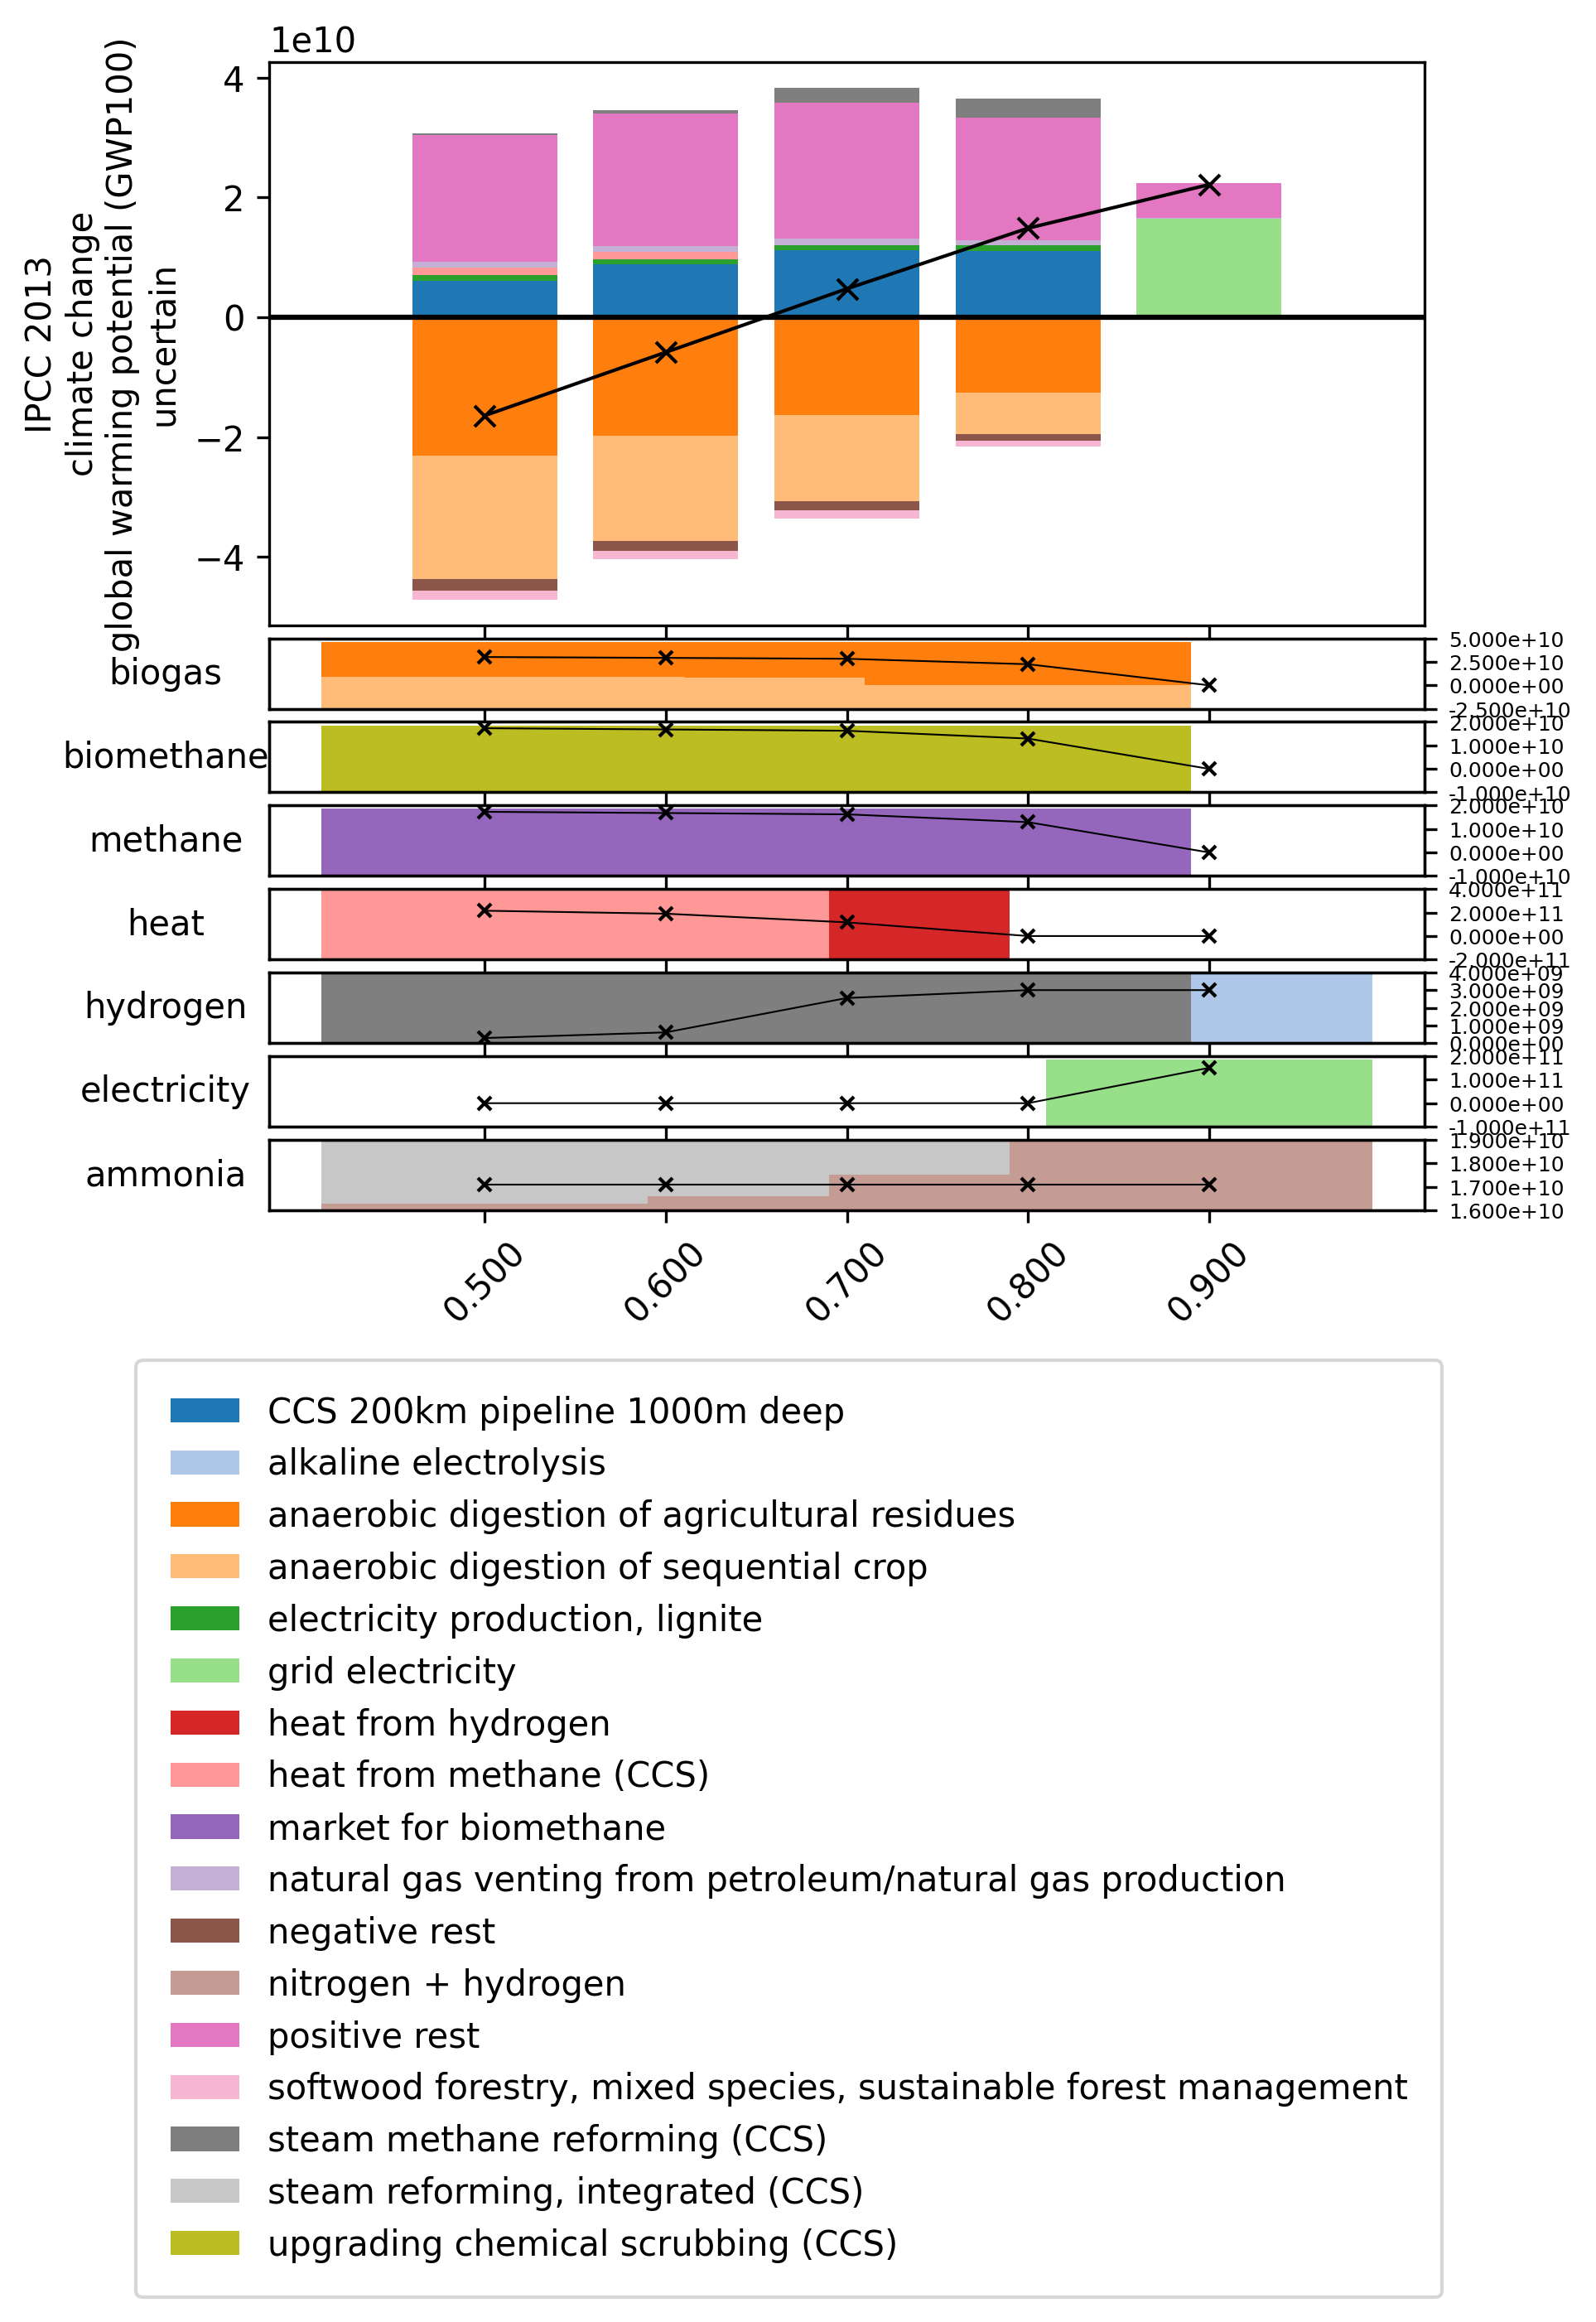

In [13]:
plots.plot_pareto_front(
    result_data_CC=results_CC, 
    cutoff_value=0.015, 
    method="\n".join(method.split("'")[1::2]), 
    process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
    bbox_to_anchor=(0.45,-3.),
    cmap_name='tab20',
    group_act_by='process'
    )

## 6.3. Iterating the epistemic uncertainty

### Updating the epistemic uncertainty factors
- All uncertainty factors linked to the availability of the biomass 

### Modelling the updated uncertain factors
- Adding/Updating variable bounds to the biomass availabilities
- Adding triangular probability distribution on the var bounds 

# Supplementary code:


## Computing the environmental cost variance and mean of the alternative technologies

In [ ]:
import ast
import bw2calc
# Copied from "ParameterFilter.construct_scaling_vector_from_choices"
# Changed the self values and moved all computation to inner most loop and moved the demand dict initialization there
#--------------------
scaling_vector_collection = {}
for product, alternatives in pulpo_worker.choices.items():
    # demand_amount = self.result_data['Choices'][product]["Value"].sum()
    for alternative in alternatives:
        print(f'Conducting LCA for {alternative}')
        demand = {alternative: 1}
        # demand[alternative] = 1
        # Compute the scaling vector for the set constructed demand
        method_tuple = ast.literal_eval(next(iter(pulpo_worker.method)))
        lca = bw2calc.LCA(demand, method_tuple)
        lca = bw2calc.LCA(demand, method_tuple)
        lca.lci()
        # Map the scaling vector results of the LCI calculation back to the optimization results index structure
        index_mapper_df = pd.concat(
            [
                pd.DataFrame.from_dict(pulpo_worker.lci_data['process_map'], orient='index', columns=['opt_problem']),
                pd.DataFrame.from_dict(lca.product_dict, orient='index', columns=['lca'])
            ],
            axis=1
        ).set_index('opt_problem')
        reindex_supply_array_df = index_mapper_df.merge(pd.DataFrame(lca.supply_array,  columns=['supply_array']), how='left', left_on='lca', right_index=True)
        scaling_vector_series = reindex_supply_array_df['supply_array']
        scaling_vector_collection[alternative] = scaling_vector_series

Compute the impact results of each alternative from the environmental costs and with the environmental cost variance

In [ ]:
from scipy.stats import norm

In [ ]:
lambda_env_cost = 0.9
ppf_lambda_QB = norm.ppf(lambda_env_cost)
normal_env_cost_df = pd.DataFrame.from_dict(normal_metadata_env_cost, orient='index')[['loc', 'scale']]
normal_env_cost_df.index = normal_env_cost_df.index.droplevel(1)
impact_results = {}
for alternative, alternative_scaling_vector in scaling_vector_collection.items():
    alternative_scaling_vector = alternative_scaling_vector.reindex(normal_env_cost_df.index)
    impact_results[alternative] = {}
    impact_results[alternative]['mean'] = alternative_scaling_vector @ normal_env_cost_df['loc']
    impact_results[alternative]['std'] = alternative_scaling_vector @ normal_env_cost_df['scale']
    impact_results[alternative][f'lambda {lambda_env_cost}'] = alternative_scaling_vector @ (normal_env_cost_df['scale'] * ppf_lambda_QB)


In [ ]:
pd.DataFrame(impact_results).T